In [2]:
!pip install gensim
import gensim.downloader
model = gensim.downloader.load('glove-wiki-gigaword-100')
model["tower"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 75.7 MB/s eta 0:00:00
[==================================================] 100.0% 128.1/128.1MB downloaded


array([ 0.49798  , -0.19195  , -0.042257 ,  0.30716  ,  0.14201  ,
       -0.17802  , -0.5812   ,  0.099506 ,  0.10369  ,  0.34719  ,
        1.4765   ,  0.29315  ,  0.050309 ,  0.38625  , -0.010546 ,
       -0.48825  ,  0.028371 ,  0.37205  , -0.054587 , -0.97034  ,
       -0.2739   , -0.17088  , -0.40007  , -0.82484  ,  1.2213   ,
       -0.57755  , -0.047156 ,  0.42659  , -0.81127  ,  0.13567  ,
        0.24373  , -0.017225 ,  0.59778  ,  0.88357  , -0.031276 ,
        0.1912   ,  0.09285  , -0.34527  ,  0.90167  , -0.32842  ,
       -0.047498 , -0.21357  , -0.040807 ,  0.18054  ,  1.0713   ,
        0.41459  ,  0.61106  ,  0.41474  ,  0.44509  ,  0.14558  ,
       -0.21622  ,  0.041226 ,  0.0071143,  0.87695  , -0.036756 ,
       -2.6578   , -0.24284  , -0.10768  ,  1.1065   ,  0.39281  ,
       -0.4001   ,  0.49402  ,  0.061114 ,  0.45835  , -0.29885  ,
       -0.44187  , -0.095089 ,  0.56715  , -0.27861  , -0.1292   ,
       -0.39259  ,  0.041889 ,  0.21763  , -0.15758  ,  0.5018

In [3]:
# Find the top 10 most similar words to 'tower'
similar_words = model.most_similar('tower', topn=10)
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

towers: 0.8470
building: 0.7259
dome: 0.6875
spire: 0.6808
gate: 0.6714
skyscraper: 0.6700
roof: 0.6561
walls: 0.6557
built: 0.6550
buildings: 0.6522


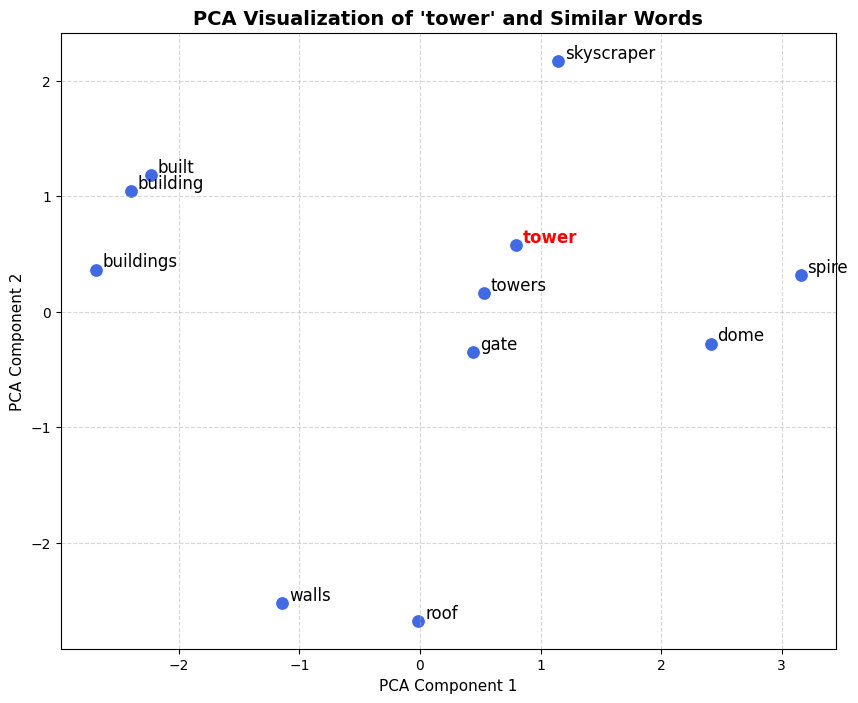

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Prepare the words and their vectors
words = ['tower'] + [w for w, _ in similar_words]
word_vectors = np.array([model[word] for word in words])

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)

# Plotting the coordinates
plt.figure(figsize=(10, 8))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], s=100, color='royalblue')

# Annotate the points with their corresponding words
for i, word in enumerate(words):
    # Bold the target word 'tower' and offset annotations slightly
    weight = 'bold' if word == 'tower' else 'normal'
    color = 'red' if word == 'tower' else 'black'
    plt.annotate(word, xy=(coords[i, 0], coords[i, 1]),
                 xytext=(5, 2), textcoords='offset points',
                 fontsize=12, weight=weight, color=color)

plt.title("PCA Visualization of 'tower' and Similar Words", fontsize=14, weight='bold')
plt.xlabel('PCA Component 1', fontsize=11)
plt.ylabel('PCA Component 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


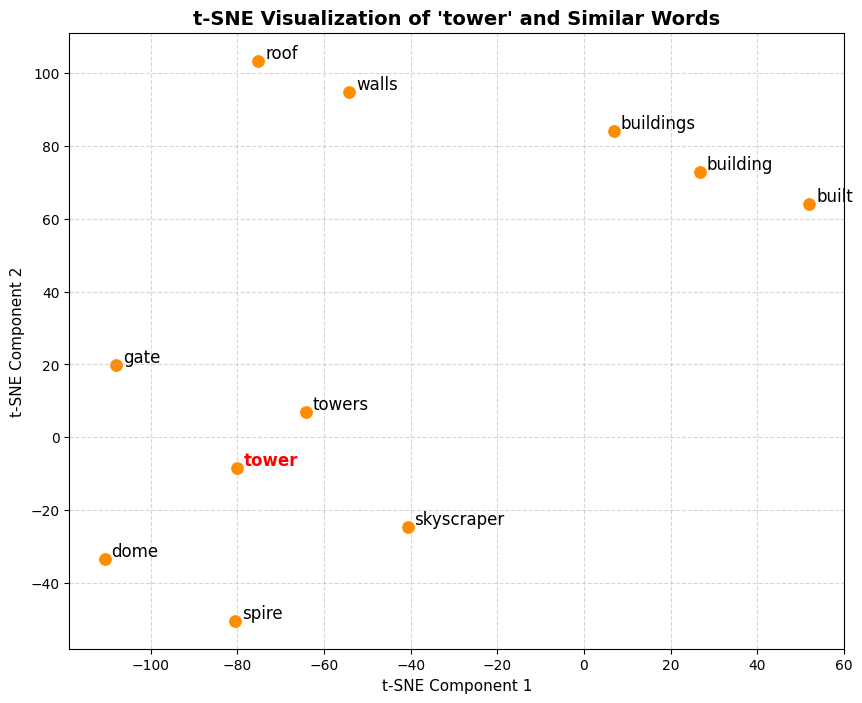

In [5]:
from sklearn.manifold import TSNE

# Reduce dimensions to 2D using t-SNE
# With only 11 samples, we use a low perplexity
tsne = TSNE(n_components=2, perplexity=3, random_state=42, n_iter=1000)
coords_tsne = tsne.fit_transform(word_vectors)

# Plotting the t-SNE coordinates
plt.figure(figsize=(10, 8))
sns.scatterplot(x=coords_tsne[:, 0], y=coords_tsne[:, 1], s=100, color='darkorange')

# Annotate the points with their corresponding words
for i, word in enumerate(words):
    weight = 'bold' if word == 'tower' else 'normal'
    color = 'red' if word == 'tower' else 'black'
    plt.annotate(word, xy=(coords_tsne[i, 0], coords_tsne[i, 1]),
                 xytext=(5, 2), textcoords='offset points',
                 fontsize=12, weight=weight, color=color)

plt.title("t-SNE Visualization of 'tower' and Similar Words", fontsize=14, weight='bold')
plt.xlabel('t-SNE Component 1', fontsize=11)
plt.ylabel('t-SNE Component 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [6]:
# Perform vector arithmetic: king - man + woman
result = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)

print("Result of 'king' - 'man' + 'woman':")
for word, similarity in result:
    print(f"{word}: {similarity:.4f}")

Result of 'king' - 'man' + 'woman':
queen: 0.7699
monarch: 0.6843
throne: 0.6756
daughter: 0.6595
princess: 0.6521


In [7]:
def plot_word_embeddings(model, target_word, method='pca', topn=10, perplexity=3, random_state=42):
    """
    Plots the 2D projection of a target word and its most similar neighbors
    using either 'pca' or 'tsne'.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    import seaborn as sns

    # 1. Retrieve similar words
    try:
        similar_words = model.most_similar(target_word, topn=topn)
    except KeyError:
        print(f"Word '{target_word}' not in the model vocabulary.")
        return

    words = [target_word] + [w for w, _ in similar_words]
    word_vectors = np.array([model[word] for word in words])

    # 2. Perform dimensionality reduction
    if method.lower() == 'pca':
        reducer = PCA(n_components=2)
        title_method = "PCA"
    elif method.lower() == 'tsne':
        # Perplexity must be smaller than the number of samples
        actual_perplexity = min(perplexity, len(words) - 1)
        reducer = TSNE(n_components=2, perplexity=actual_perplexity, random_state=random_state, max_iter=1000)
        title_method = "t-SNE"
    else:
        raise ValueError("Method must be either 'pca' or 'tsne'.")

    coords = reducer.fit_transform(word_vectors)

    # 3. Plot
    plt.figure(figsize=(10, 8))
    color = 'royalblue' if method.lower() == 'pca' else 'darkorange'
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], s=100, color=color)

    # Annotate points
    for i, word in enumerate(words):
        weight = 'bold' if word == target_word else 'normal'
        text_color = 'red' if word == target_word else 'black'
        plt.annotate(word, xy=(coords[i, 0], coords[i, 1]),
                     xytext=(5, 2), textcoords='offset points',
                     fontsize=12, weight=weight, color=text_color)

    plt.title(f"{title_method} Visualization of '{target_word}' and Similar Words", fontsize=14, weight='bold')
    plt.xlabel(f'{title_method} Component 1', fontsize=11)
    plt.ylabel(f'{title_method} Component 2', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

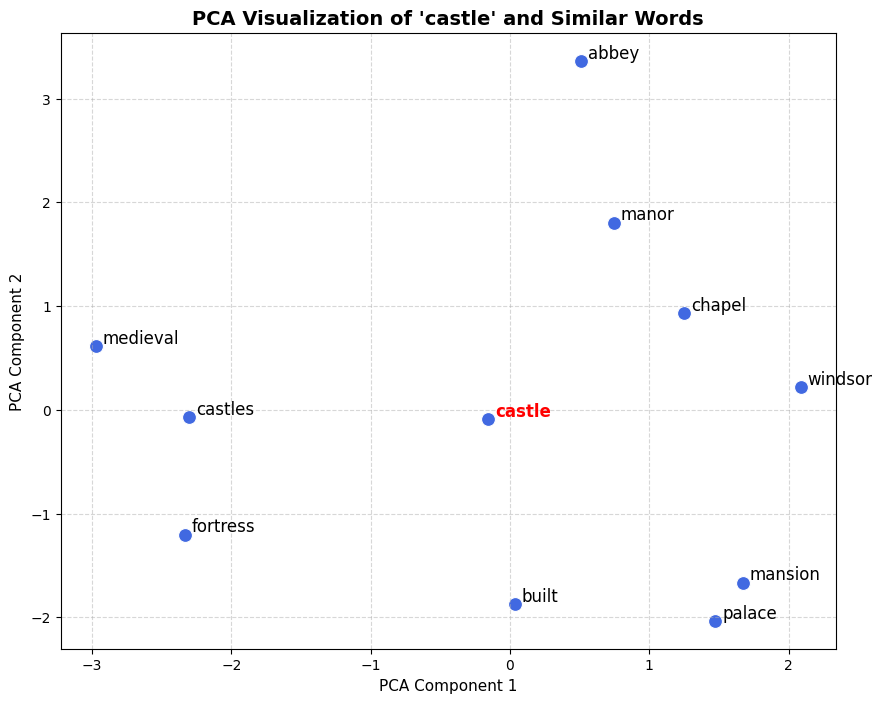

In [8]:
# Demonstration of the helper function
plot_word_embeddings(model, target_word='castle', method='pca', topn=10)

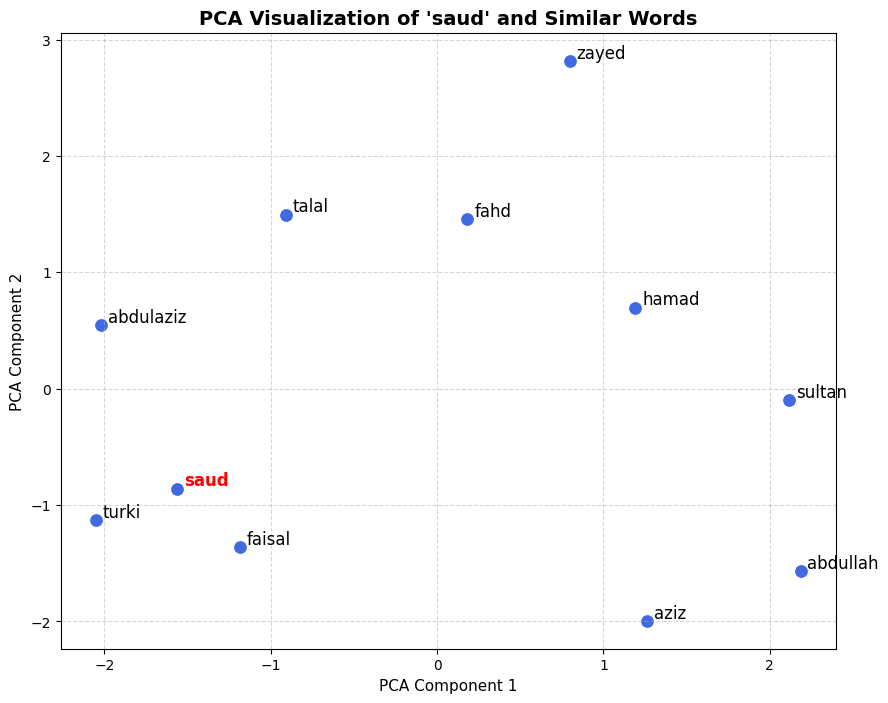

In [9]:
# Demonstration of the helper function
plot_word_embeddings(model, target_word='saud', method='pca', topn=10)

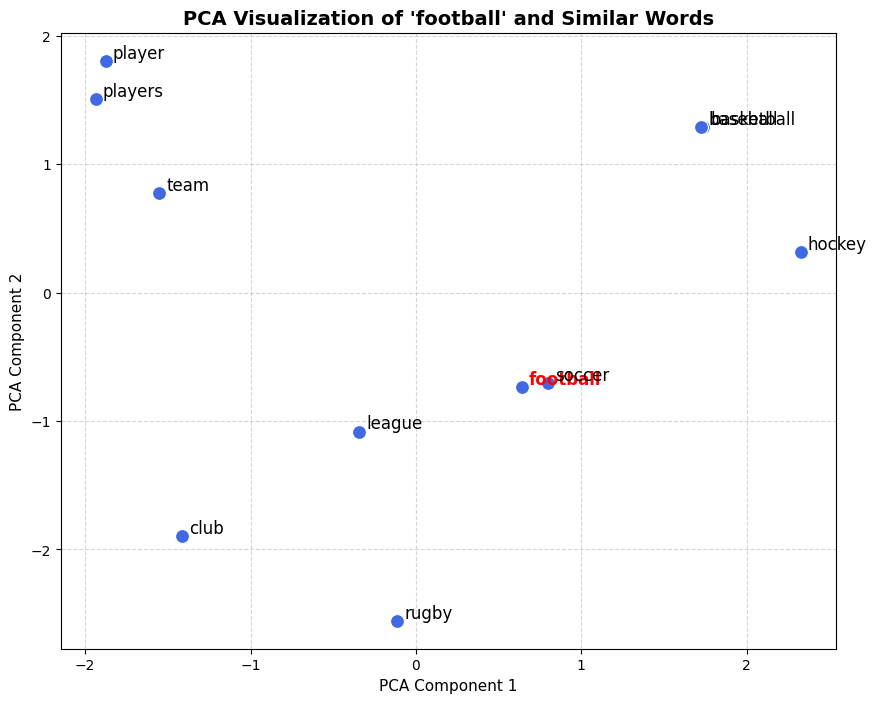

In [11]:
# Demonstration of the helper function
plot_word_embeddings(model, target_word='football', method='pca', topn=10)

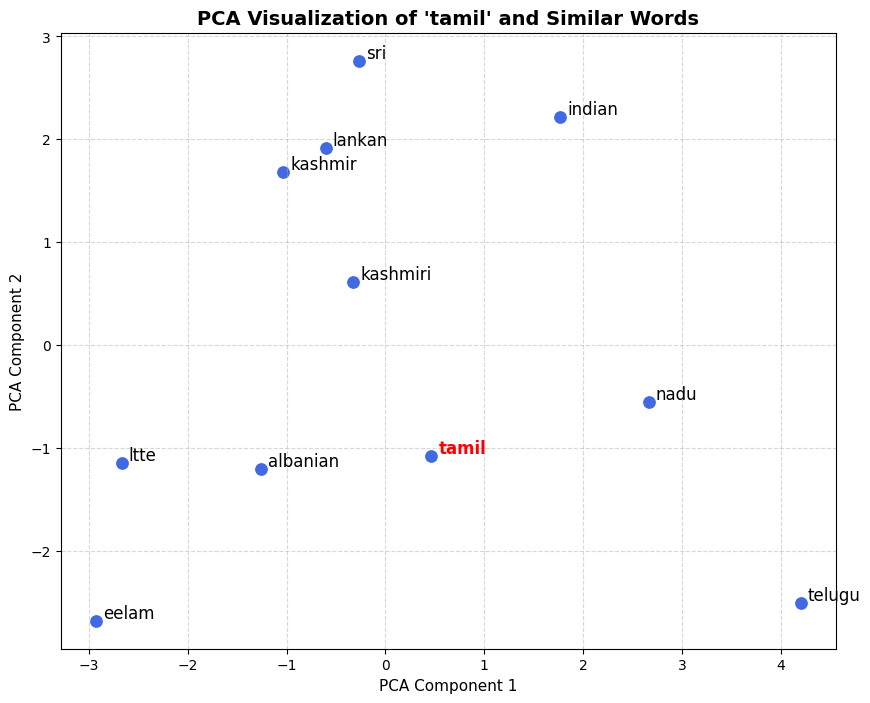

In [12]:
# Demonstration of the helper function
plot_word_embeddings(model, target_word='tamil', method='pca', topn=10)